In [1]:
# Import the necessary packages
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Ensure reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

In [3]:
# This transform duplicates the 1 channel into 3
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # shape: [1, 28, 28]
    #transforms.Lambda(lambda x: x.repeat(3, 1, 1))  # shape: [3, 28, 28]
])

In [4]:
class MMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()

        # Define fully connected layers explicitly
        self.fc1 = nn.Linear(3 * 224 * 224, 4096)
        self.fc2 = nn.Linear(4096, 2048)
        self.fc3 = nn.Linear(2048, 1024)
        self.fc4 = nn.Linear(1024, 512)
        self.fc5 = nn.Linear(512, 5)  # output layer for 5 classes

    def forward(self, x):
        x = self.flatten(x)
        self.h1 = F.relu(self.fc1(x))
        self.h2 = F.relu(self.fc2(self.h1))
        self.h3 = F.relu(self.fc3(self.h2))
        self.h4 = F.relu(self.fc4(self.h3))
        out = self.fc5(self.h4)
        return out

In [6]:
model_caltech42 = MMLP().to('cuda')
model_caltech113 = MMLP().to('cuda')
model_labelme42 = MMLP().to('cuda')
model_labelme113 = MMLP().to('cuda')
model_sun42 = MMLP().to('cuda')
model_sun113 = MMLP().to('cuda')
model_voc42 = MMLP().to('cuda')
model_voc113 = MMLP().to('cuda')

In [7]:
model_caltech42.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_caltech101_mul42.pth"))
model_caltech113.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_caltech101_mul113.pth"))
model_labelme42.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_labelme_mul42.pth"))
model_labelme113.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_labelme_mul42.pth"))
model_sun42.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_sun09_mul42.pth"))
model_sun113.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_sun09_mul113.pth"))
model_voc42.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_voc2007_mul42.pth"))
model_voc113.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_voc2007_mul113.pth"))


/tmp/ipykernel_1257781/438486196.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_caltech42.load_state_dict(torch.load("../finetuned_weights/VLCS/vlcs_caltech101_mu

<All keys matched successfully>

In [8]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [9]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

# your transform
vlcs_transforms = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor()
])

# load the dataset from one root directory with subfolders 0-9
caltech = datasets.ImageFolder(root="/home/aban/circuit_tracing/VLCS/Caltech101", transform=vlcs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(caltech))
test_size = len(caltech) - train_size

caltech_train_dataset, caltech_test_dataset = random_split(caltech, [train_size, test_size], generator=generator)

print(f"Train size: {len(caltech_train_dataset)}")
print(f"Test size: {len(caltech_test_dataset)}")

#Load the artpainting dataset
caltech_train_loader = DataLoader(caltech_train_dataset, batch_size=1024, shuffle=True, generator=generator)
caltech_test_loader = DataLoader(caltech_test_dataset, batch_size=1024, shuffle=False)

Train size: 1132
Test size: 283


In [10]:
# load the dataset from one root directory with subfolders 0-9
labelme = datasets.ImageFolder(root="/home/aban/circuit_tracing/VLCS/LabelMe", transform=vlcs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(labelme))
test_size = len(labelme) - train_size

labelme_train_dataset, labelme_test_dataset = random_split(labelme, [train_size, test_size], generator=generator)

print(f"Train size: {len(labelme_train_dataset)}")
print(f"Test size: {len(labelme_test_dataset)}")

#Load the artpainting dataset
labelme_train_loader = DataLoader(labelme_train_dataset, batch_size=64, shuffle=True, generator=generator)
labelme_test_loader = DataLoader(labelme_test_dataset, batch_size=64, shuffle=False)

Train size: 2124
Test size: 532


In [11]:
# load the dataset from one root directory with subfolders 0-9
sun = datasets.ImageFolder(root="/home/aban/circuit_tracing/VLCS/SUN09", transform=vlcs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(sun))
test_size = len(sun) - train_size

sun_train_dataset, sun_test_dataset = random_split(sun, [train_size, test_size], generator=generator)

print(f"Train size: {len(sun_train_dataset)}")
print(f"Test size: {len(sun_test_dataset)}")

#Load the artpainting dataset
sun_train_loader = DataLoader(sun_train_dataset, batch_size=64, shuffle=True, generator=generator)
sun_test_loader = DataLoader(sun_test_dataset, batch_size=64, shuffle=False)

Train size: 2625
Test size: 657


In [12]:
# load the dataset from one root directory with subfolders 0-9
voc = datasets.ImageFolder(root="/home/aban/circuit_tracing/VLCS/VOC2007", transform=vlcs_transforms)


# set generator with fixed seed
generator = torch.Generator().manual_seed(42)

# sizes for train/test split (e.g., 80/20)
train_size = int(0.8 * len(voc))
test_size = len(voc) - train_size

voc_train_dataset, voc_test_dataset = random_split(voc, [train_size, test_size], generator=generator)

print(f"Train size: {len(voc_train_dataset)}")
print(f"Test size: {len(voc_test_dataset)}")

#Load the artpainting dataset
voc_train_loader = DataLoader(voc_train_dataset, batch_size=64, shuffle=True, generator=generator)
voc_test_loader = DataLoader(voc_test_dataset, batch_size=64, shuffle=False)

Train size: 2700
Test size: 676


In [13]:
@torch.no_grad()
def compute_mean_hidden_by_class_deep(model: nn.Module, dataloader, device='cuda'):
    """
    Compute mean ReLU activations per class for all hidden layers h1..h4.
    Returns:
        mean_hidden: dict { 'h1': Tensor[C, H1], 'h2': Tensor[C, H2], ... }
        counts: Tensor[C] number of examples per class
    """
    model.eval().to(device)
    C = model.fc5.out_features
    layers = ['h1', 'h2', 'h3', 'h4']
    hidden_sizes = {
        'h1': model.fc1.out_features,
        'h2': model.fc2.out_features,
        'h3': model.fc3.out_features,
        'h4': model.fc4.out_features
    }

    sums = {k: torch.zeros(C, hidden_sizes[k], device=device) for k in layers}
    counts = torch.zeros(C, dtype=torch.long, device=device)

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        _ = model(x)  # populates model.h1..h4
        B = y.size(0)
        # for each layer, accumulate per-class sums
        for k in layers:
            a = getattr(model, k)  # (B, Hk)
            for c in torch.unique(y):
                mask = (y == c)
                if mask.any():
                    sums[k][int(c)] += a[mask].sum(0)
        # update counts
        batch_counts = torch.bincount(y, minlength=C).to(device)
        counts += batch_counts

    mean_hidden = {}
    for k in layers:
        # avoid division by zero
        denom = counts.float().clamp(min=1.0).unsqueeze(1)  # (C,1)
        mean_hidden[k] = sums[k] / denom  # (C, Hk)
    return mean_hidden, counts


In [14]:
@torch.no_grad()
def build_class_circuit_record_deep_recursive(
    model: nn.Module,
    mean_hidden: dict,
    class_id: int,
    top_hidden_per_layer: int = 20,
    top_inputs_per_hidden: int = 50,
    positive_only: bool = True,
    device='cuda'
):
    """
    Build a circuit record for `class_id` that includes selected hidden units
    from all hidden layers (h1..h4) and their kept incoming edges.

    Structure returned:
    {
      'class': int,
      'hidden_nodes': {
         'h1': { idx: { ... }, ... },
         'h2': { idx: {...}, ... },
         ...
      },
      'output_node': { 'w_in_vec_from_hidden': [...] },  # W5[class,:]
      'meta': { ... }
    }
    """
    model = model.to(device).eval()

    # Extract weights (layer naming: fc1: input->h1, fc2: h1->h2, ...)
    W1 = model.fc1.weight.detach().to(device)  # (H1, D)
    b1 = model.fc1.bias.detach().to(device)
    W2 = model.fc2.weight.detach().to(device)  # (H2, H1)
    b2 = model.fc2.bias.detach().to(device)
    W3 = model.fc3.weight.detach().to(device)  # (H3, H2)
    b3 = model.fc3.bias.detach().to(device)
    W4 = model.fc4.weight.detach().to(device)  # (H4, H3)
    b4 = model.fc4.bias.detach().to(device)
    W5 = model.fc5.weight.detach().to(device)  # (C, H4)
    b5 = model.fc5.bias.detach().to(device)

    C = W5.size(0)
    H1, D = W1.size(0), W1.size(1)
    H2 = W2.size(0)
    H3 = W3.size(0)
    H4 = W4.size(0)

    # 1) Compute effective contribution weights from *each hidden unit* to the class
    # eff_h4 = W5[class,:]                 shape (H4,)
    # eff_h3 = W4.T @ eff_h4               shape (H3,)
    # eff_h2 = W3.T @ eff_h3               shape (H2,)
    # eff_h1 = W2.T @ eff_h2               shape (H1,)
    eff = {}
    eff['h4'] = W5[class_id].clone().to(device)        # (H4,)
    eff['h3'] = W4.t().matmul(eff['h4'])               # (H3,)
    eff['h2'] = W3.t().matmul(eff['h3'])               # (H2,)
    eff['h1'] = W2.t().matmul(eff['h2'])               # (H1,)

    if positive_only:
        for k in eff: eff[k] = torch.clamp(eff[k], min=0.0)

    # 2) For each layer, pick top units and keep their top incoming edges
    hidden_nodes = {}
    layer_info = [
        ('h4', W4, None),  # incoming to h4 comes from h3 via W4 (W4[h4, h3])
        ('h3', W3, None),
        ('h2', W2, None),
        ('h1', W1, None)   # incoming to h1 comes from raw input via W1 (W1[h1, i])
    ]
    # Note: we iterate in top-down order just for readability (h4 -> h1)
    for layer_name, W_in, _ in layer_info:
        H = eff[layer_name].numel()
        keepH = min(int(top_hidden_per_layer), int(H))
        # Choose top units by eff weight magnitude (or signed if use positive_only=False)
        vals, idx = torch.topk(eff[layer_name].abs() if positive_only else eff[layer_name],
                               k=keepH, largest=True, sorted=True)
        layer_dict = {}
        for h in idx.tolist():
            # incoming weights vector for this unit -> select top-K by abs
            win_vec = W_in[h]  # shape depends: for h1 -> W1[h] shape (D,), for others -> shape (H_prev,)
            keepK = min(int(top_inputs_per_hidden), win_vec.numel())
            k_vals, k_idx = torch.topk(win_vec.abs(), k=keepK, largest=True, sorted=True)

            # Build small dict of kept incoming edges: index -> signed weight
            edge_in = {int(i): float(win_vec[int(i)].item()) for i in k_idx.tolist()}

            # outgoing vector: weights from this hidden unit to the next layer
            # for h4 outgoing to outputs (W5[:, h4]); for others outgoing to next hidden layer W_{l+1}[:, h]
            if layer_name == 'h4':
                w_out_vec = W5[:, h].detach().cpu().numpy().tolist()  # shape (C,)
                edge_weight_to_class = float(W5[class_id, h].item())
            elif layer_name == 'h3':
                w_out_vec = W4[:, h].detach().cpu().numpy().tolist()  # contributions to h4 units
                # effective weight to class is eff['h3'][h]
                edge_weight_to_class = float(eff['h3'][h].item())
            elif layer_name == 'h2':
                w_out_vec = W3[:, h].detach().cpu().numpy().tolist()
                edge_weight_to_class = float(eff['h2'][h].item())
            elif layer_name == 'h1':
                w_out_vec = W2[:, h].detach().cpu().numpy().tolist()
                edge_weight_to_class = float(eff['h1'][h].item())
            else:
                w_out_vec = []
                edge_weight_to_class = 0.0

            layer_dict[int(h)] = {
                'w_in_vec': [float(v) for v in win_vec.detach().cpu().numpy()],   # full incoming vector
                'edge_weights_in': edge_in,                                       # kept inputs only
                'w_out_vec': w_out_vec,                                           # outgoing vector to next-layer or outputs
                'edge_weight_to_class': edge_weight_to_class                      # effective weight to class (scalar)
            }
        hidden_nodes[layer_name] = layer_dict

    # 3) Output node row (W5[class,:])
    output_row = W5[class_id].detach().cpu().numpy().tolist()

    record = {
        'class': int(class_id),
        'hidden_nodes': hidden_nodes,
        'output_node': {
            'w_in_vec_from_hidden': output_row
        },
        'meta': {
            'input_shape': (3, 224, 224),
            'flat_input_dim': int(W1.size(1)),
            'hidden_layers': [int(H1), int(H2), int(H3), int(H4)],
            'layer_names': ['h1', 'h2', 'h3', 'h4'],
            'num_classes': int(C),
            'top_hidden_per_layer': int(top_hidden_per_layer),
            'top_inputs_per_hidden': int(top_inputs_per_hidden),
            'positive_only': bool(positive_only)
        }
    }
    return record


In [15]:
@torch.no_grad()
def build_all_class_circuits_deep_recursive(model: nn.Module,
                                            dataloader,
                                            top_hidden_per_layer: int = 20,
                                            top_inputs_per_hidden: int = 50,
                                            positive_only: bool = True,
                                            device='cuda'):
    mean_hidden, counts = compute_mean_hidden_by_class_deep(model, dataloader, device=device)
    circuits = {}
    C = model.fc5.out_features
    for c in range(C):
        circuits[c] = build_class_circuit_record_deep_recursive(
            model, mean_hidden, class_id=c,
            top_hidden_per_layer=top_hidden_per_layer,
            top_inputs_per_hidden=top_inputs_per_hidden,
            positive_only=positive_only,
            device=device
        )
    return circuits


In [16]:
def circuit_to_graph_deep(circ, use_abs_edges=True, directed=True):
    """
    Build a graph with nodes:
      - ("x", i)      input pixel nodes (only those that appear in kept edges)
      - ("h1", h), ("h2", h), ...
      - ("c", class)
    Edges correspond to kept incoming edges in circ['hidden_nodes'] and the selected
    outgoing edges are not added unless they appear as incoming on downstream nodes
    (so we do not duplicate edges).
    Edge attribute name: 'weight' (absolute or signed depending on use_abs_edges)
    """
    G = nx.DiGraph() if directed else nx.Graph()
    c = circ['class']
    G.add_node(("c", c), kind="class")

    hidden_nodes = circ['hidden_nodes']  # dict: layer_name -> { idx: rec, ... }

    # Add hidden nodes and their incoming edges (only those kept in edge_weights_in)
    for layer_name, nodes in hidden_nodes.items():
        for h_idx, rec in nodes.items():
            node_h = (layer_name, int(h_idx))
            G.add_node(node_h, kind="hidden", layer=layer_name)
            # incoming edges: indices refer to previous-layer indices or input indices
            # Determine source node prefix:
            if layer_name == 'h1':
                # inputs
                for i, w in rec['edge_weights_in'].items():
                    src = ("x", int(i))
                    if not G.has_node(src):
                        G.add_node(src, kind="input")
                    wv = abs(w) if use_abs_edges else w
                    if wv != 0.0:
                        G.add_edge(src, node_h, weight=float(wv))
            else:
                # previous hidden layer name:
                prev_layer = 'h' + str(int(layer_name[1:]) - 1)
                for i, w in rec['edge_weights_in'].items():
                    src = (prev_layer, int(i))
                    if not G.has_node(src):
                        # add the previous hidden node even if we didn't select it above (safe)
                        G.add_node(src, kind="hidden", layer=prev_layer)
                    wv = abs(w) if use_abs_edges else w
                    if wv != 0.0:
                        G.add_edge(src, node_h, weight=float(wv))

            # Add outgoing edge to class only for final hidden layer h4 (if present)
            if layer_name == 'h4':
                w_to_class = rec.get('edge_weight_to_class', 0.0)
                wv = abs(w_to_class) if use_abs_edges else w_to_class
                if wv != 0.0:
                    G.add_edge(node_h, ("c", c), weight=float(wv))

    return G


In [17]:
def _l2norm(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    n = np.linalg.norm(x)
    return x / (n + eps)

In [18]:
def vectorize_class_circuit_deep(circ, use_abs_edges=True, include_bias=False):
    """
    Builds a vector per class:
      - input_vec (length D): aggregated contributions from selected h1 nodes (kept edges),
      - eff_layer_concat: concatenation of effective weights from selected nodes per layer (h1..h4),
      - out_vec: the W5[class,:] row (abs if requested)
    The blocks are L2-normalized individually then concatenated.
    """
    meta = circ['meta']
    D = meta['flat_input_dim']
    layer_names = meta['layer_names']  # ['h1','h2','h3','h4']

    # (1) Input aggregate: sum over kept h1 nodes: eff(h1) * w_in[h1, i]
    input_vec = np.zeros(D, dtype=np.float64)
    h1_nodes = circ['hidden_nodes'].get('h1', {})
    for h, rec in h1_nodes.items():
        eff_h = abs(rec['edge_weight_to_class']) if use_abs_edges else rec['edge_weight_to_class']
        for i, w_in in rec['edge_weights_in'].items():
            input_vec[int(i)] += float(w_in) * float(eff_h)

    # (2) per-layer eff vectors: for each layer concatenate kept nodes' edge_weight_to_class in layer order
    eff_blocks = []
    for layer in layer_names:
        nodes = circ['hidden_nodes'].get(layer, {})
        if len(nodes) == 0:
            eff_blocks.append(np.zeros(1, dtype=np.float64))
            continue
        eff_arr = np.zeros(len(nodes), dtype=np.float64)
        for k_idx, (h_idx, rec) in enumerate(sorted(nodes.items())):
            v = rec.get('edge_weight_to_class', 0.0)
            eff_arr[k_idx] = abs(v) if use_abs_edges else v
        eff_blocks.append(_l2norm(eff_arr))

    eff_concat = np.concatenate(eff_blocks, axis=0)

    # (3) output node row
    out_vec = np.asarray(circ['output_node']['w_in_vec_from_hidden'], dtype=np.float64)
    if use_abs_edges:
        out_vec = np.abs(out_vec)

    # Normalize each main block
    b0 = _l2norm(input_vec)
    b1 = _l2norm(eff_concat)
    b2 = _l2norm(out_vec)

    v = np.concatenate([b0, b1, b2], axis=0)
    return v


In [19]:
def _cos01(u, v, eps=1e-12):
    u = np.asarray(u, dtype=np.float64)
    v = np.asarray(v, dtype=np.float64)
    nu = np.linalg.norm(u); nv = np.linalg.norm(v)
    if nu < eps or nv < eps:
        return 0.0
    cos = float(np.dot(u, v) / (nu * nv))
    return 0.5 * (cos + 1.0)  # map [-1,1] -> [0,1]

In [20]:
def similarity_matrix_from_vectors(vA, vB):
    """
    vA/vB: {class_id -> vector}
    Returns:
      S[i,j] = cosine01( vA[class_i], vB[class_j] ), classes = sorted keys
    """
    classes = sorted(set(vA.keys()) | set(vB.keys()))
    n = len(classes)
    S = np.zeros((n, n), dtype=np.float64)
    for i, ca in enumerate(classes):
        for j, cb in enumerate(classes):
            S[i, j] = _cos01(vA[ca], vB[cb])
    return S, classes

In [21]:
def plot_similarity_matrix_with_values(
    S, classes=None, title="Circuit Similarity (A vs B)",
    figsize=(6,5), cmap='viridis', fmt=".2f", text_size=8
):
    """
    S: (10,10) numpy array with values in [0,1]
    Shows a heatmap and writes each value in the cell.
    """
    n = S.shape[0]
    if classes is None:
        classes = list(range(n))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S, vmin=0.65, vmax=0.80, cmap=cmap, origin='upper')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    ax.set_xlabel("Classes in B")
    ax.set_ylabel("Classes in A")
    ax.set_title(title)

    # Annotate values
    thresh = (S.max() + S.min()) / 2.0
    for i in range(n):
        for j in range(n):
            color = 'white' if S[i, j] > thresh else 'black'
            ax.text(j, i, format(S[i, j], fmt),
                    ha='center', va='center', color=color, fontsize=text_size)

    # Optional: faint grid for readability
    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.25, color='w', alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    plt.tight_layout()
    plt.show()

In [22]:
def frobenius_diff(similarity_matrix: np.ndarray) -> float:
    C = similarity_matrix.shape[0]  # number of classes
    identity = np.eye(C)
    diff = similarity_matrix - identity
    frob_norm = np.linalg.norm(diff, 'fro')  # Frobenius norm
    return frob_norm

In [23]:
from graphkitlearn.gklearn.kernels.treeletKernel import treeletkernel
from graphkitlearn.gklearn.utils.kernels import highest_polynomial_kernel
import numpy as np
import matplotlib.pyplot as plt

def score_from_cm(cm2x2):
    """Compute a scalar score from a 2×2 confusion-like matrix."""
    cm = cm2x2.astype(float)
    return (cm[0,0] + cm[1,1]) / cm.sum() if cm.sum() > 0 else 0.0


def treelet_similarity_matrix_deep(circuits_A, circuits_B, sub_kernel=''):
    """
    Computes the Treelet Kernel similarity matrix between two sets of DEEP circuits.
    Each circuit is converted to a graph using circuit_to_graph_deep().
    
    Returns:
        S : np.ndarray [10x10]
            Normalized similarity matrix in [0,1].
        classes : list[str]
            Sorted class labels used for rows/cols.
    """
    classes = sorted(circuits_A.keys())
    n_classes = len(classes)

    # 1️⃣ Convert each deep circuit into a weighted directed graph
    GA = [circuit_to_graph_deep(circuits_A[c], use_abs_edges=True) for c in classes]
    GB = [circuit_to_graph_deep(circuits_B[c], use_abs_edges=True) for c in classes]

    # 2️⃣ Compute all 10×10 Treelet kernels between circuits_A and circuits_B
    mat_scores = np.zeros((n_classes, n_classes), dtype=np.float64)

    for i in range(n_classes):
        for j in range(n_classes):
            try:
                # treeletkernel returns a (2×2) matrix of confusion-like scores
                K, idx = treeletkernel(
                    GA[i], GB[j],
                    n_jobs=None,
                    chunksize=None,
                    verbose=False,
                    sub_kernel=sub_kernel,
                    parallel=None
                )
                mat_scores[i, j] = score_from_cm(K)
            except Exception as e:
                print(f"⚠️ Treelet kernel failed for ({classes[i]}, {classes[j]}):", e)
                mat_scores[i, j] = 0.0

    # 3️⃣ Normalize to [0,1]
    S = mat_scores.copy()
    S = (S - S.min()) / (S.max() - S.min() + 1e-12)

    # 4️⃣ Enforce diagonal dominance (optional stabilization)
    for i in range(n_classes):
        S[i, i] = max(S[i, i], S[i, :].max() + 1e-3)

    # 5️⃣ Clip again to [0,1]
    S = np.clip(S, 0, 1)

    return S, classes


In [24]:
def plot_treelet_similarity_matrix_with_values(S, classes=None,
                                               title="Treelet Circuit Similarity (Deep A vs B)",
                                               figsize=(6, 5), cmap='viridis',
                                               fmt=".2f", text_size=8):
    n = S.shape[0]
    if classes is None:
        classes = list(range(n))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S, vmin=0.0, vmax=1.0, cmap=cmap, origin='upper')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(n)); ax.set_yticks(np.arange(n))
    ax.set_xticklabels(classes); ax.set_yticklabels(classes)
    ax.set_xlabel("Classes in B"); ax.set_ylabel("Classes in A")
    ax.set_title(title)

    thresh = (S.max() + S.min()) / 2.0
    for i in range(n):
        for j in range(n):
            color = 'white' if S[i, j] > thresh else 'black'
            ax.text(j, i, format(S[i, j], fmt),
                    ha='center', va='center', color=color, fontsize=text_size)

    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', linestyle='-', linewidth=0.25, color='w', alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    plt.tight_layout()
    plt.show()


In [25]:
circuits_caltech42 = build_all_class_circuits_deep_recursive(
    model_caltech42,
    caltech_train_loader,
    top_hidden_per_layer=5,
    top_inputs_per_hidden=10,
    positive_only=True,
    device='cuda'
)
circuits_caltech113 = build_all_class_circuits_deep_recursive(
    model_caltech113,
    caltech_train_loader,
    top_hidden_per_layer=5,
    top_inputs_per_hidden=10,
    positive_only=True,
    device='cuda'
)

circuits_labelme42 = build_all_class_circuits_deep_recursive(
    model_labelme42,
    labelme_train_loader,
    top_hidden_per_layer=5,
    top_inputs_per_hidden=10,
    positive_only=True,
    device='cuda'
)

circuits_labelme113 = build_all_class_circuits_deep_recursive(
    model_labelme113,
    labelme_train_loader,
    top_hidden_per_layer=5,
    top_inputs_per_hidden=10,
    positive_only=True,
    device='cuda'
)

circuits_sun42 = build_all_class_circuits_deep_recursive(
    model_sun42,
    sun_train_loader,
    top_hidden_per_layer=5,
    top_inputs_per_hidden=10,
    positive_only=True,
    device='cuda'
)

circuits_sun113 = build_all_class_circuits_deep_recursive(
    model_sun113,
    sun_train_loader,
    top_hidden_per_layer=5,
    top_inputs_per_hidden=10,
    positive_only=True,
    device='cuda'
)

circuits_voc42 = build_all_class_circuits_deep_recursive(
    model_voc42,
    voc_train_loader,
    top_hidden_per_layer=5,
    top_inputs_per_hidden=10,
    positive_only=True,
    device='cuda'
)

circuits_voc113 = build_all_class_circuits_deep_recursive(
    model_voc113,
    voc_train_loader,
    top_hidden_per_layer=5,
    top_inputs_per_hidden=10,
    positive_only=True,
    device='cuda'
)


In [26]:
vectors_caltech42 = {
    c: vectorize_class_circuit_deep(rec, use_abs_edges=True, include_bias=False)
                for c, rec in circuits_caltech42.items()}
vectors_caltech113 = {
    c: vectorize_class_circuit_deep(rec, use_abs_edges=True, include_bias=False)
                for c, rec in circuits_caltech113.items()}
vectors_labelme42 = {
    c: vectorize_class_circuit_deep(rec, use_abs_edges=True, include_bias=False)
                for c, rec in circuits_labelme42.items()}
vectors_labelme113 = {
    c: vectorize_class_circuit_deep(rec, use_abs_edges=True, include_bias=False)
                for c, rec in circuits_labelme113.items()}
vectors_sun42 = {
    c: vectorize_class_circuit_deep(rec, use_abs_edges=True, include_bias=False)
                for c, rec in circuits_sun42.items()}
vectors_sun113 = {
    c: vectorize_class_circuit_deep(rec, use_abs_edges=True, include_bias=False)
                for c, rec in circuits_sun113.items()}
vectors_voc42 = {
    c: vectorize_class_circuit_deep(rec, use_abs_edges=True, include_bias=False)
                for c, rec in circuits_voc42.items()}
vectors_voc113 = {
    c: vectorize_class_circuit_deep(rec, use_abs_edges=True, include_bias=False)
                for c, rec in circuits_voc113.items()}

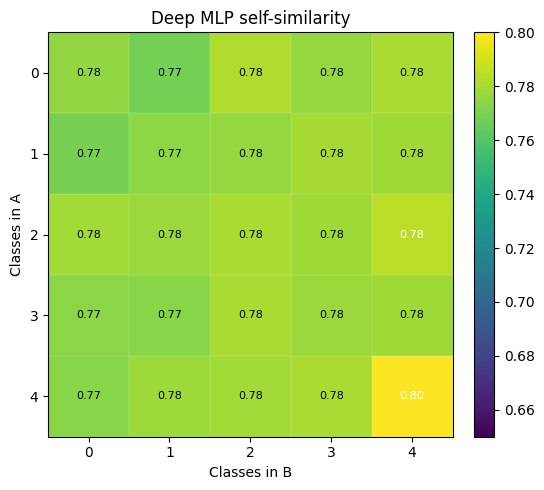

Frobenius norm: 3.5112992864484345
mean(diagonal)=0.782, mean(off-diagonal)=0.777


In [27]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_caltech42, vectors_caltech113)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

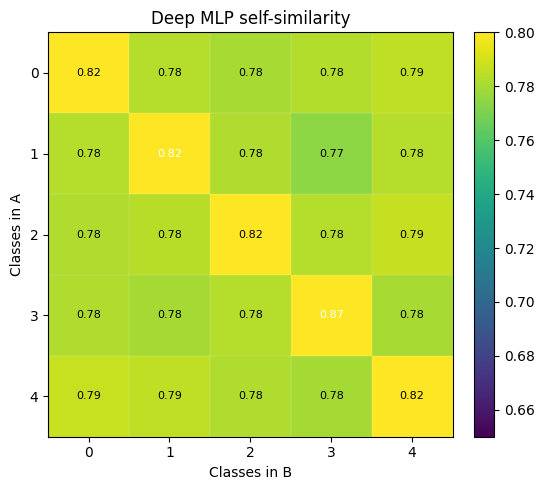

Frobenius norm: 3.5216421844839663
mean(diagonal)=0.828, mean(off-diagonal)=0.783


In [28]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_caltech42, vectors_labelme42)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

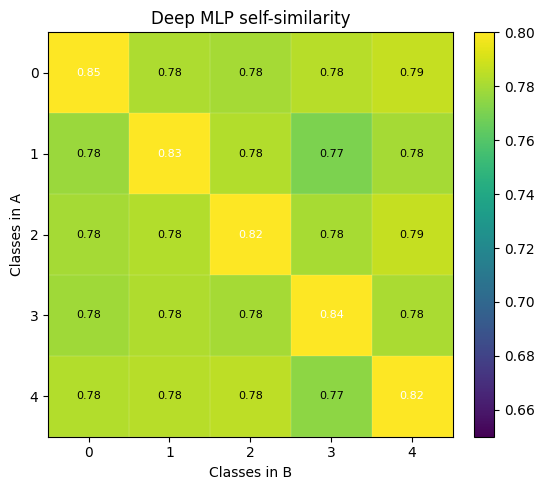

Frobenius norm: 3.5135066561612955
mean(diagonal)=0.830, mean(off-diagonal)=0.781


In [30]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_caltech42, vectors_sun42)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

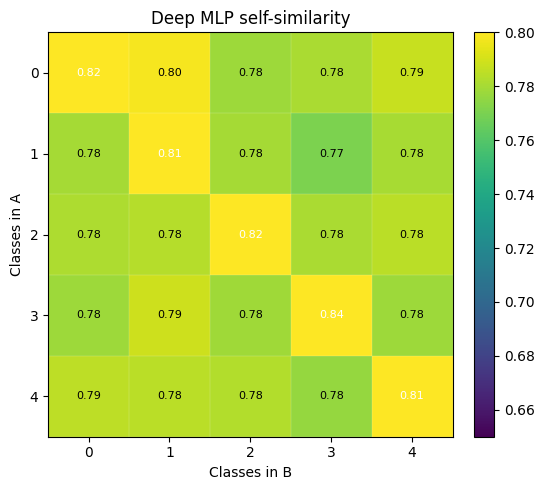

Frobenius norm: 3.5196102315176554
mean(diagonal)=0.821, mean(off-diagonal)=0.782


In [31]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_caltech42, vectors_voc42)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

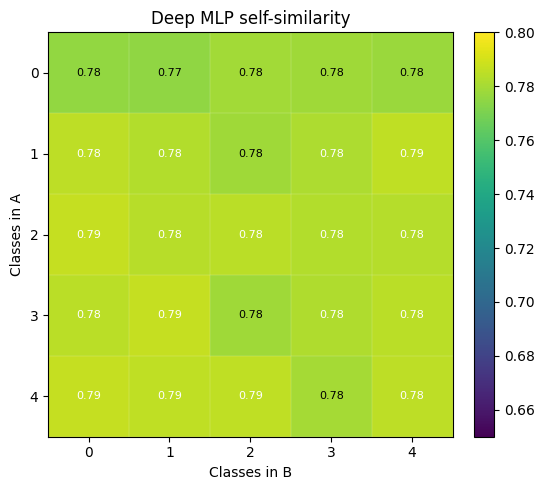

Frobenius norm: 3.5332662518225186
mean(diagonal)=0.782, mean(off-diagonal)=0.782


In [32]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_caltech113, vectors_labelme113)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

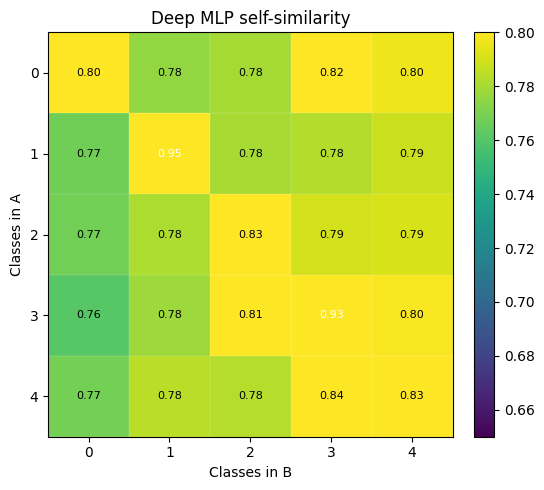

Frobenius norm: 3.5366123183569917
mean(diagonal)=0.870, mean(off-diagonal)=0.787


In [33]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_caltech113, vectors_sun113)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

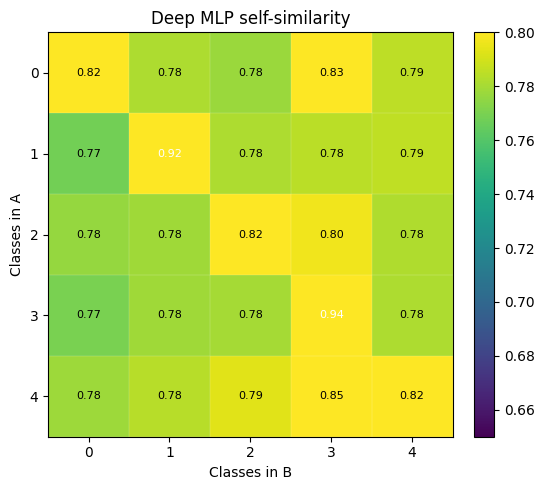

Frobenius norm: 3.533881166807379
mean(diagonal)=0.866, mean(off-diagonal)=0.787


In [34]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_caltech113, vectors_voc113)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

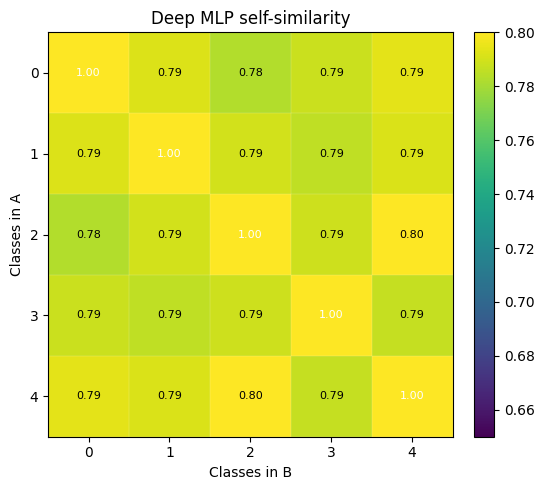

Frobenius norm: 3.5326927398702397
mean(diagonal)=1.000, mean(off-diagonal)=0.790


In [35]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_labelme42, vectors_labelme113)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

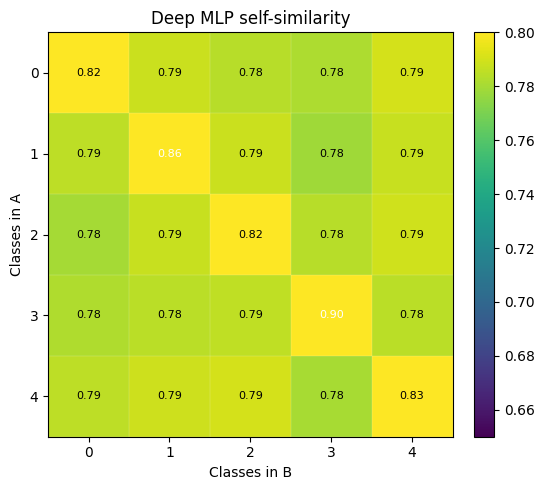

Frobenius norm: 3.5290652329917673
mean(diagonal)=0.847, mean(off-diagonal)=0.785


In [36]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_labelme42, vectors_sun42)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

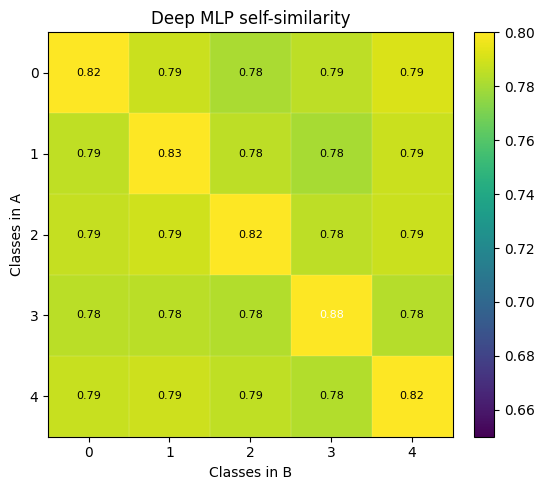

Frobenius norm: 3.5327887292032663
mean(diagonal)=0.836, mean(off-diagonal)=0.786


In [37]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_labelme42, vectors_voc42)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

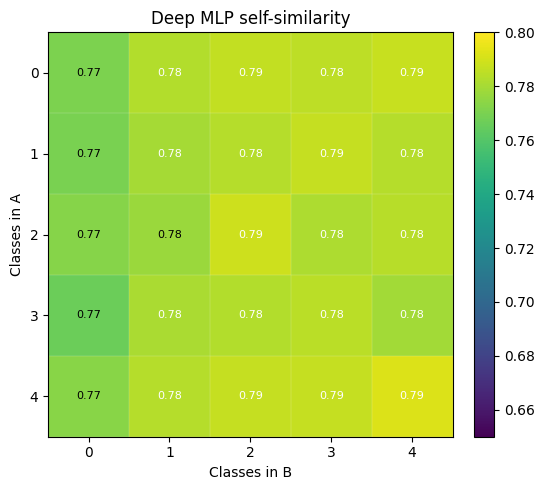

Frobenius norm: 3.526139486710582
mean(diagonal)=0.783, mean(off-diagonal)=0.781


In [38]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_labelme113, vectors_sun113)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

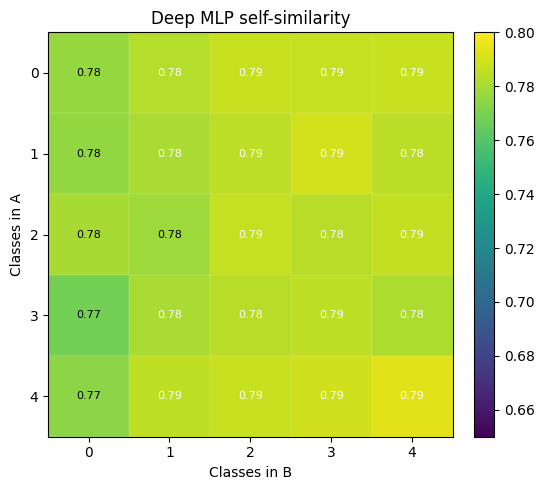

Frobenius norm: 3.534658428969093
mean(diagonal)=0.785, mean(off-diagonal)=0.783


In [39]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_labelme113, vectors_voc113)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

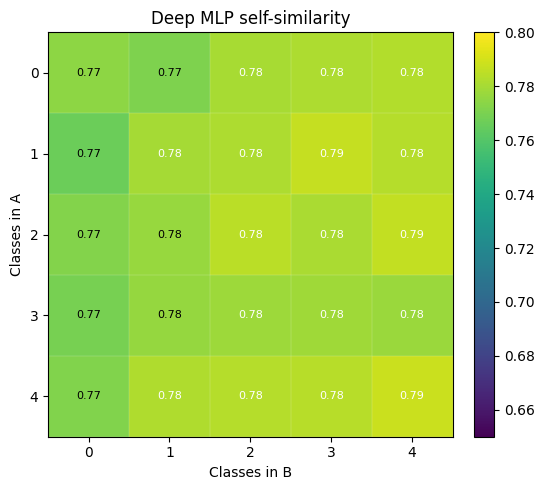

Frobenius norm: 3.5165883359464805
mean(diagonal)=0.781, mean(off-diagonal)=0.779


In [40]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_sun42, vectors_sun113)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

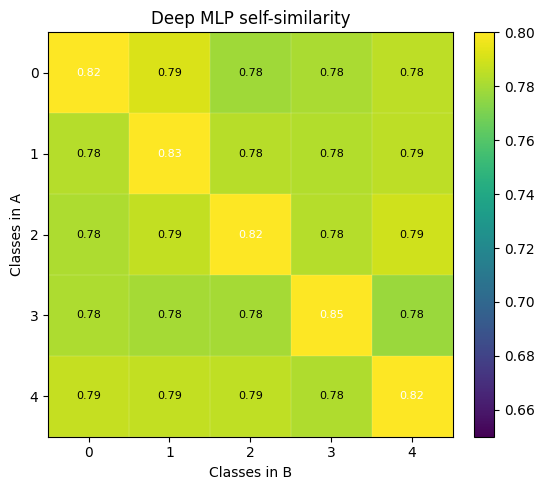

Frobenius norm: 3.525056438187208
mean(diagonal)=0.828, mean(off-diagonal)=0.784


In [41]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_sun42, vectors_voc42)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

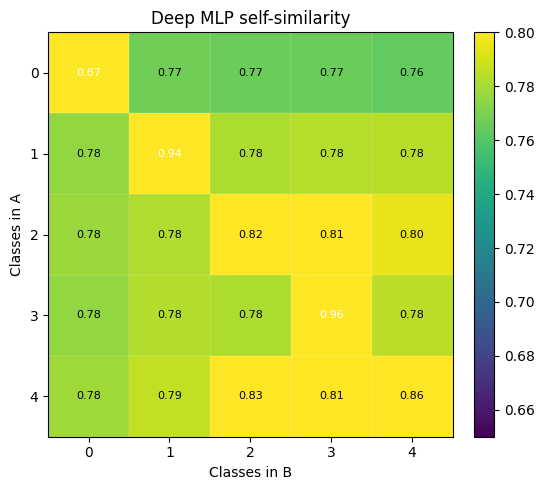

Frobenius norm: 3.5189561711795
mean(diagonal)=0.891, mean(off-diagonal)=0.784


In [42]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_sun113, vectors_voc113)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

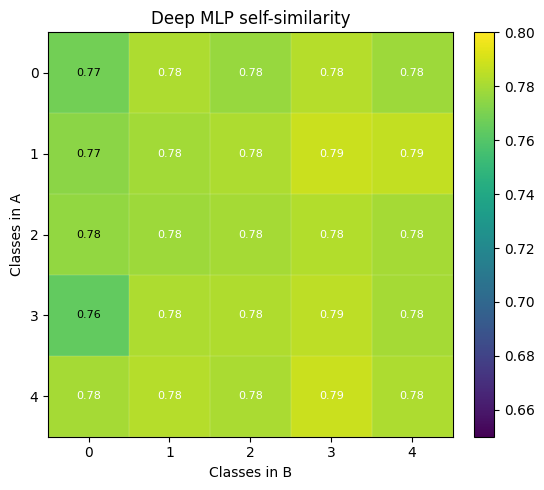

Frobenius norm: 3.5242028745517717
mean(diagonal)=0.779, mean(off-diagonal)=0.780


In [43]:
# Similarity matrix
S, classes = similarity_matrix_from_vectors(vectors_voc42, vectors_voc113)  # self-similarity
%matplotlib inline
plot_similarity_matrix_with_values(S, classes, title="Deep MLP self-similarity")
frob_norm = frobenius_diff(S)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S))
off  = (S.sum() - np.trace(S)) / (S.size - len(S))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

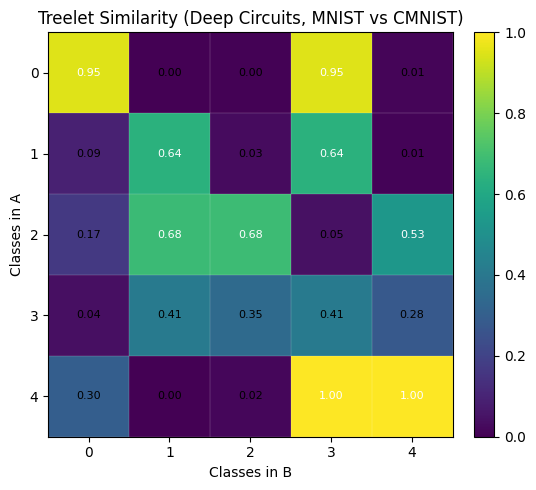

Frobenius norm: 2.033269104765054
mean(diagonal)=0.738, mean(off-diagonal)=0.278


In [44]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_caltech42,
    circuits_caltech113,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

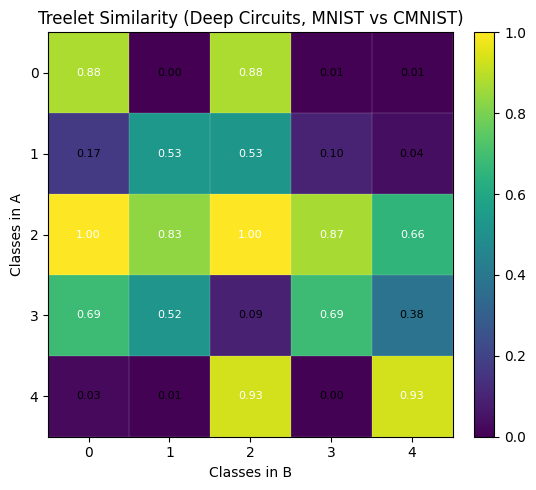

Frobenius norm: 2.4652666599344757
mean(diagonal)=0.806, mean(off-diagonal)=0.387


In [45]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_caltech42,
    circuits_labelme42,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

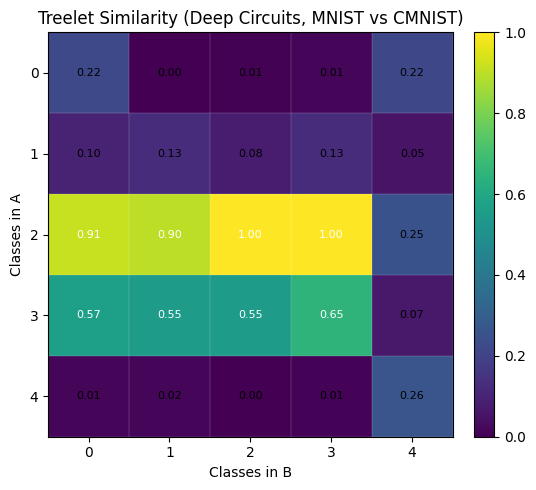

Frobenius norm: 2.3979701368350885
mean(diagonal)=0.452, mean(off-diagonal)=0.271


In [46]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_caltech42,
    circuits_sun42,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

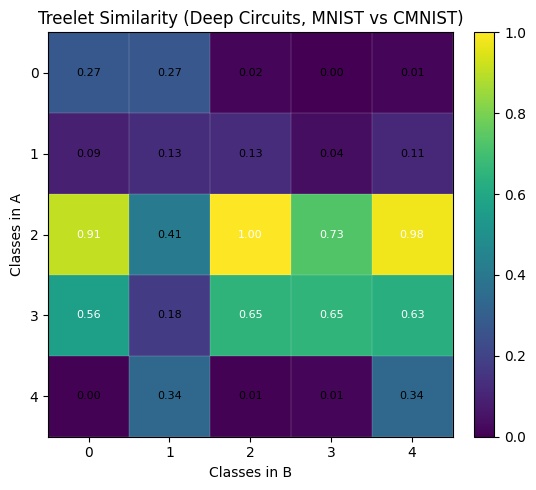

Frobenius norm: 2.391420874290903
mean(diagonal)=0.479, mean(off-diagonal)=0.304


In [47]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_caltech42,
    circuits_voc42,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

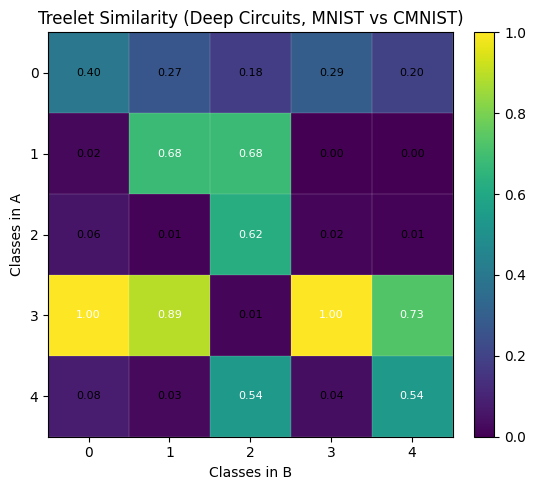

Frobenius norm: 2.036339674827799
mean(diagonal)=0.648, mean(off-diagonal)=0.253


In [48]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_caltech113,
    circuits_labelme113,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

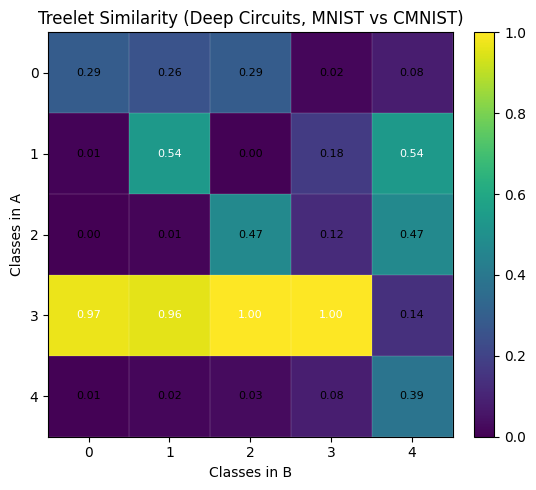

Frobenius norm: 2.2315431194699173
mean(diagonal)=0.538, mean(off-diagonal)=0.260


In [49]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_caltech113,
    circuits_sun113,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

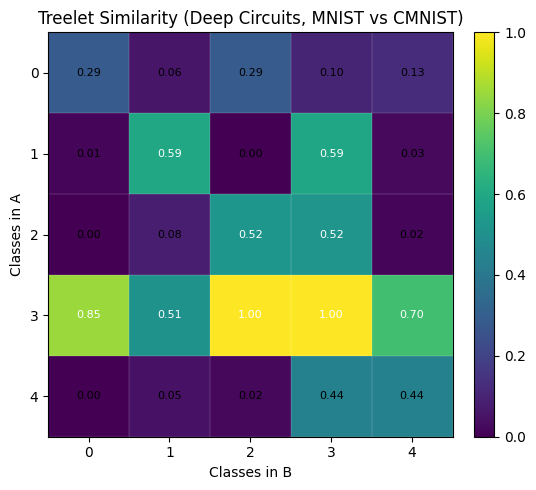

Frobenius norm: 2.149542083688157
mean(diagonal)=0.569, mean(off-diagonal)=0.270


In [50]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_caltech113,
    circuits_voc113,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

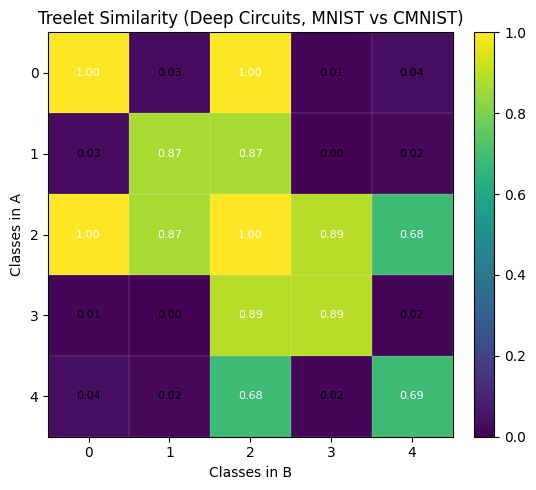

Frobenius norm: 2.4840358382280936
mean(diagonal)=0.890, mean(off-diagonal)=0.357


In [51]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_labelme42,
    circuits_labelme113,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

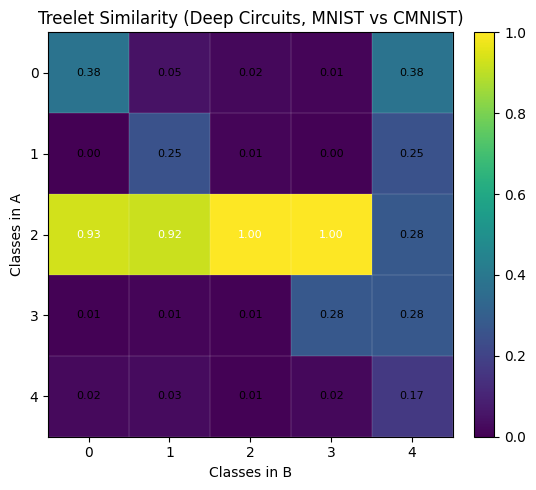

Frobenius norm: 2.2904967801372167
mean(diagonal)=0.415, mean(off-diagonal)=0.212


In [52]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_labelme42,
    circuits_sun42,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

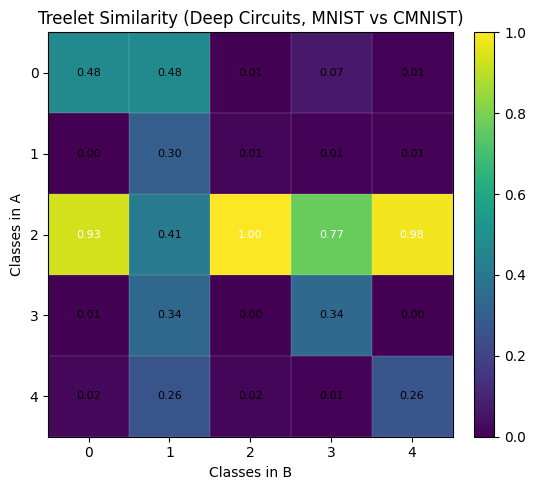

Frobenius norm: 2.1769531850968686
mean(diagonal)=0.477, mean(off-diagonal)=0.217


In [53]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_labelme42,
    circuits_voc42,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

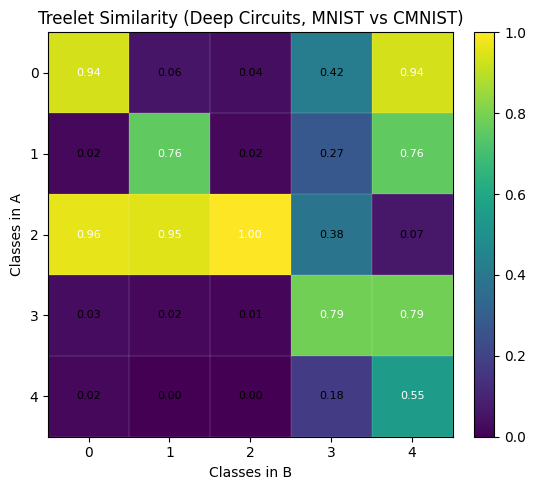

Frobenius norm: 2.1557901693701784
mean(diagonal)=0.807, mean(off-diagonal)=0.297


In [54]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_labelme113,
    circuits_sun113,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

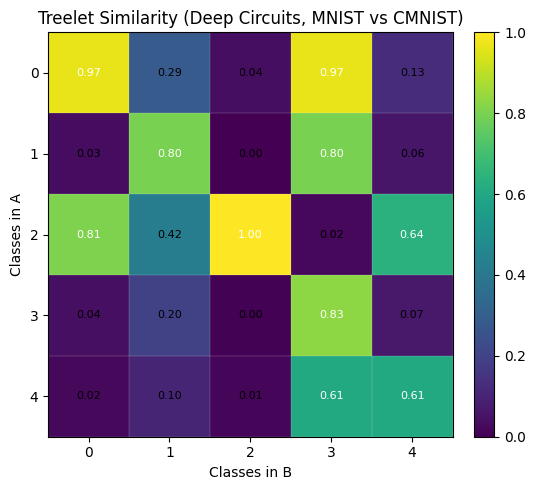

Frobenius norm: 1.8888034678541636
mean(diagonal)=0.841, mean(off-diagonal)=0.263


In [55]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_labelme113,
    circuits_voc113,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

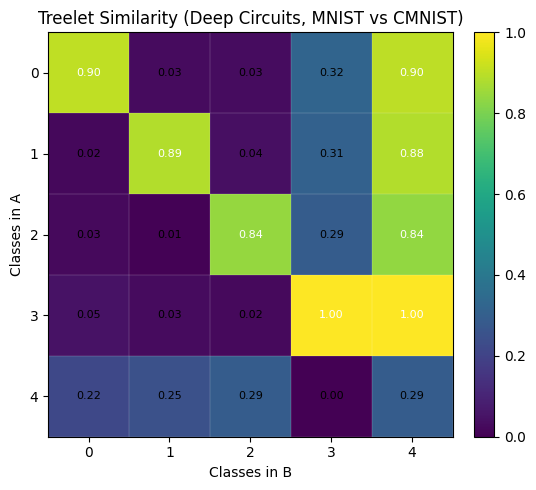

Frobenius norm: 2.0828653157854893
mean(diagonal)=0.784, mean(off-diagonal)=0.278


In [56]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_sun42,
    circuits_sun113,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

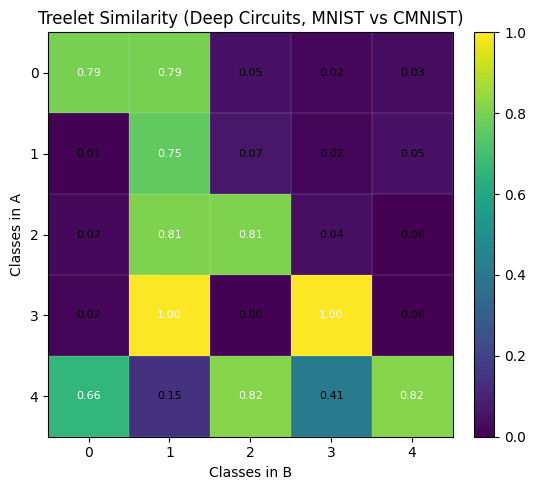

Frobenius norm: 1.9391571103863086
mean(diagonal)=0.835, mean(off-diagonal)=0.248


In [57]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_sun42,
    circuits_voc42,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

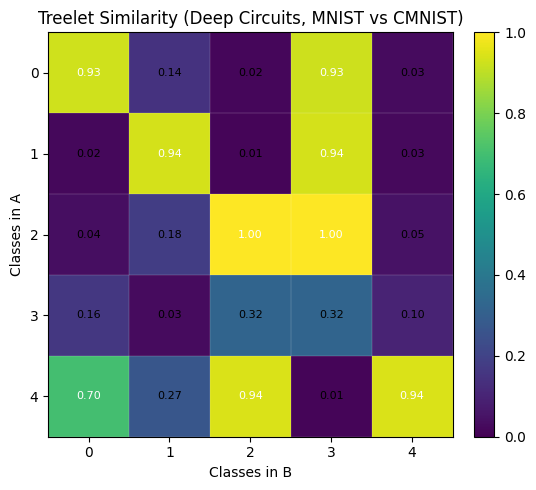

Frobenius norm: 2.2036127311064515
mean(diagonal)=0.826, mean(off-diagonal)=0.296


In [58]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_sun113,
    circuits_voc113,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")

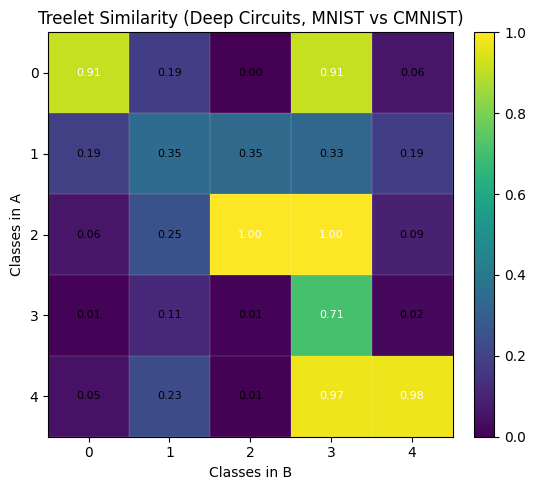

Frobenius norm: 1.9438359221341663
mean(diagonal)=0.789, mean(off-diagonal)=0.251


: 

In [ ]:
S_treelet, classes = treelet_similarity_matrix_deep(
    circuits_voc42,
    circuits_voc113,
    sub_kernel=highest_polynomial_kernel   # can be '', 'rwk', or other custom base kernels
)
%matplotlib inline
plot_treelet_similarity_matrix_with_values(
    S_treelet, classes, title="Treelet Similarity (Deep Circuits, MNIST vs CMNIST)"
)
frob_norm = frobenius_diff(S_treelet)
print("Frobenius norm:", frob_norm)
diag = np.mean(np.diag(S_treelet))
off  = (S_treelet.sum() - np.trace(S_treelet)) / (S_treelet.size - len(S_treelet))
print(f"mean(diagonal)={diag:.3f}, mean(off-diagonal)={off:.3f}")